In [1]:
# Read the .csv file and store it in a Pandas DataFrame called df. 
# Have a look at the read_csv() documentation and try to provide these column names: ['DATE', 'TAG', 'POSTS']
import pandas
from matplotlib import pyplot
df = pandas.read_csv('QueryResults.csv', header=0, names=['DATE', 'TAG', 'POSTS'])
df

,DATE,TAG,POSTS
0,2008-07-01 00:00:00,c#,3
1,2008-08-01 00:00:00,assembly,8
2,2008-08-01 00:00:00,javascript,162
3,2008-08-01 00:00:00,c,85
4,2008-08-01 00:00:00,python,124
...,...,...,...
1986,2020-07-01 00:00:00,r,5694
1987,2020-07-01 00:00:00,go,743
1988,2020-07-01 00:00:00,ruby,775
1989,2020-07-01 00:00:00,perl,182


In [2]:
#Look at the first and last 5 rows of the DataFrame.
df.head()

,DATE,TAG,POSTS
0,2008-07-01 00:00:00,c#,3
1,2008-08-01 00:00:00,assembly,8
2,2008-08-01 00:00:00,javascript,162
3,2008-08-01 00:00:00,c,85
4,2008-08-01 00:00:00,python,124


In [3]:
df.tail()

,DATE,TAG,POSTS
1986,2020-07-01 00:00:00,r,5694
1987,2020-07-01 00:00:00,go,743
1988,2020-07-01 00:00:00,ruby,775
1989,2020-07-01 00:00:00,perl,182
1990,2020-07-01 00:00:00,swift,3607


In [4]:
# How many rows and how many columns does it have?
df.shape

(1991, 3)

In [5]:
# Count the number of entries in each column.
df.count()

DATE     1991
TAG      1991
POSTS    1991
dtype: int64

In [6]:
# The TAG is the name of the programming language. So for example in July 2008, 
# there were 3 posts tagged with the language C#. Given that the TAG serves as 
# our category column, can you figure out how to count the number of posts per 
# language? Which programming language had the most number of posts since the 
# creation of Stack Overflow? (Hint: you may need to review one of yesterday's lessons).
post_per_language = df.groupby('TAG')['POSTS'].sum()
post_per_language.sort_values(ascending=False)

TAG
javascript    2056510
java          1696403
python        1496210
c#            1423530
php           1361988
c++            684210
r              356799
c              336042
swift          273055
ruby           214582
perl            65286
go              47499
delphi          46212
assembly        34852
Name: POSTS, dtype: int64

In [7]:
# Also, some languages are older like C and other languages are newer (like Swift). 
# The dataset starts in July 2008, so some languages will not have any posts for every month. 
# Can you count how many months of posts exist for each programming language?

df.groupby('TAG').count()

,DATE,POSTS
TAG,,
assembly,144,144
c,144,144
c#,145,145
c++,144,144
delphi,144,144
go,129,129
java,144,144
javascript,144,144
perl,144,144


In [8]:
# Alternatively, for column names no spaces, we can also use the dot-notation:
df['DATE'][1]
df.DATE[1]

'2008-08-01 00:00:00'

In [9]:
# Convert the string data into date time obj
type(df.DATE[1]) # str
df.DATE = pandas.to_datetime(df.DATE)
type(df.DATE)
df.head()

,DATE,TAG,POSTS
0,2008-07-01,c#,3
1,2008-08-01,assembly,8
2,2008-08-01,javascript,162
3,2008-08-01,c,85
4,2008-08-01,python,124


In [10]:
# Can you pivot the df DataFrame so that each row is a date and each column is a programming language? 
# Store the result under a variable called reshaped_df. 
reshaped = df.pivot(index='DATE', columns='TAG', values='POSTS')
reshaped.head()

TAG,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
DATE,,,,,,,,,,,,,,
2008-07-01,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-08-01,8.0,85.0,511.0,164.0,14.0,NaN,222.0,162.0,28.0,161.0,124.0,NaN,73.0,NaN
2008-09-01,28.0,321.0,1649.0,755.0,105.0,NaN,1137.0,640.0,131.0,482.0,542.0,6.0,290.0,NaN
2008-10-01,15.0,303.0,1989.0,811.0,112.0,NaN,1153.0,725.0,127.0,617.0,510.0,NaN,249.0,NaN
2008-11-01,17.0,259.0,1730.0,735.0,141.0,NaN,958.0,579.0,97.0,504.0,452.0,1.0,160.0,NaN


In [11]:
# Examine the dimensions of the reshaped DataFrame. How many rows does it have? How many columns?
reshaped.shape

(145, 14)

In [12]:
# Examine the head and the tail of the DataFrame. What does it look like?
reshaped.head()

TAG,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
DATE,,,,,,,,,,,,,,
2008-07-01,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-08-01,8.0,85.0,511.0,164.0,14.0,NaN,222.0,162.0,28.0,161.0,124.0,NaN,73.0,NaN
2008-09-01,28.0,321.0,1649.0,755.0,105.0,NaN,1137.0,640.0,131.0,482.0,542.0,6.0,290.0,NaN
2008-10-01,15.0,303.0,1989.0,811.0,112.0,NaN,1153.0,725.0,127.0,617.0,510.0,NaN,249.0,NaN
2008-11-01,17.0,259.0,1730.0,735.0,141.0,NaN,958.0,579.0,97.0,504.0,452.0,1.0,160.0,NaN


In [13]:
# Examine the head and the tail of the DataFrame. What does it look like?
reshaped.tail()

TAG,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
DATE,,,,,,,,,,,,,,
2020-03-01,317.0,2670.0,8954.0,5107.0,181.0,719.0,13253.0,20483.0,215.0,6672.0,26673.0,5761.0,780.0,3434.0
2020-04-01,406.0,3472.0,10042.0,6820.0,250.0,887.0,15377.0,24634.0,240.0,8060.0,32605.0,7047.0,860.0,4015.0
2020-05-01,386.0,3602.0,9923.0,7063.0,221.0,826.0,14711.0,25196.0,228.0,7917.0,34478.0,6833.0,774.0,4066.0
2020-06-01,363.0,2757.0,9064.0,6161.0,214.0,765.0,13015.0,23360.0,203.0,7188.0,31817.0,6249.0,670.0,3733.0
2020-07-01,298.0,2294.0,9145.0,5756.0,212.0,743.0,12723.0,23802.0,182.0,7334.0,31261.0,5694.0,775.0,3607.0


In [14]:
# Print out the column names.
reshaped.columns


Index(['assembly', 'c', 'c#', 'c++', 'delphi', 'go', 'java', 'javascript',
       'perl', 'php', 'python', 'r', 'ruby', 'swift'],
      dtype='str', name='TAG')

In [15]:
# Count the number of entries per column.
reshaped.count()

TAG
assembly      144
c             144
c#            145
c++           144
delphi        144
go            129
java          144
javascript    144
perl          144
php           144
python        144
r             142
ruby          144
swift         135
dtype: int64

In [16]:
# When we count the number of entries per column we see that not all languages are the same. 
# The reason is that the .count() method excludes NaN values. 
# When we pivoted the DataFrame the NaN values were inserted when there were no posts for a language in that month
# In this case, we don't want to drop the rows that have a NaN value. 
# Instead, we want to substitute the number 0 for each NaN value in the DataFrame. 
# We can do this with the .fillna() method.

reshaped.fillna(0, inplace=True)
reshaped.count()

TAG
assembly      145
c             145
c#            145
c++           145
delphi        145
go            145
java          145
javascript    145
perl          145
php           145
python        145
r             145
ruby          145
swift         145
dtype: int64

In [17]:
# Here we are using the .isna() method that we've used before, but we're chaining two more things: 
# the values attribute and the any() method. This means we don't have to search through the entire 
# DataFrame to spot if .isna() is True.
reshaped.isna().values.any()

np.False_

In [18]:
reshaped['java']

DATE
2008-07-01        0.0
2008-08-01      222.0
2008-09-01     1137.0
2008-10-01     1153.0
2008-11-01      958.0
               ...   
2020-03-01    13253.0
2020-04-01    15377.0
2020-05-01    14711.0
2020-06-01    13015.0
2020-07-01    12723.0
Name: java, Length: 145, dtype: float64

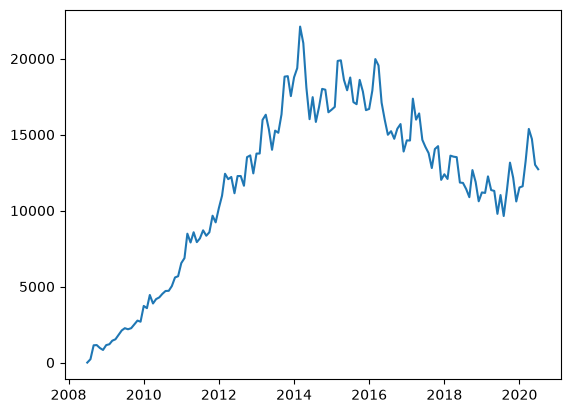

In [19]:
# You can actually show a line chart for the popularity of a programming language using only a single line of code. 
# Can you use the .plot() documentation to figure out how to do this? 
# Can you use the .plot() documentation to figure out how to do this? 
# Try and plot the popularity of the Java programming language

java_plot = pyplot.plot(reshaped.index, reshaped.java)


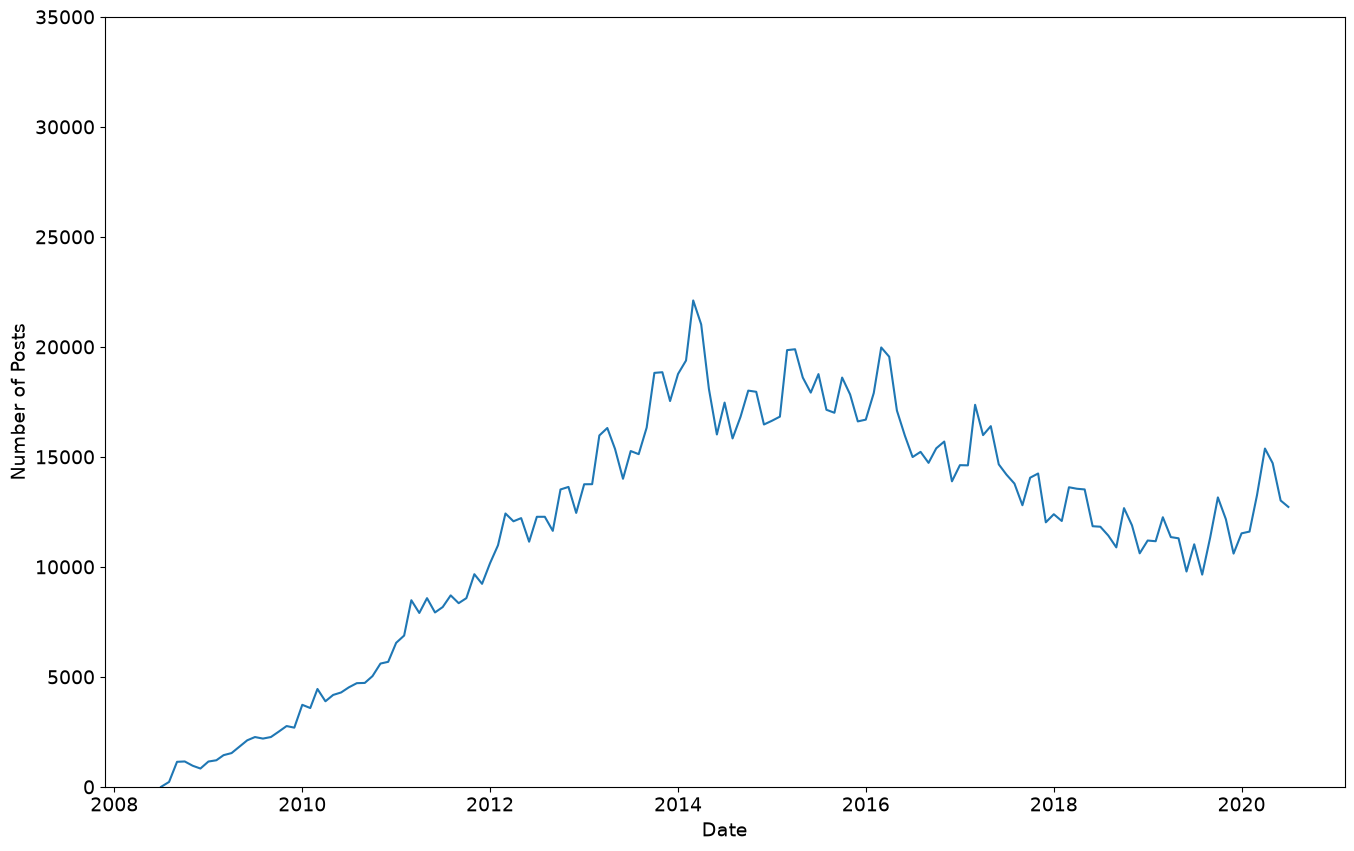

In [20]:
# To make our chart larger we can provide a width (16) and a height (10) as the figsize of the figure.
pyplot.figure(figsize=(16, 10))
pyplot.xticks(fontsize=14)
pyplot.yticks(fontsize=14)
# Now we can add labels. Also, we're never going to get less than 0 posts, so let's set a lower limit of 0 
# for the y-axis with .ylim().
pyplot.xlabel('Date', fontsize=14)
pyplot.ylabel('Number of Posts', fontsize=14)
pyplot.ylim(0, 35000)
pyplot.plot(reshaped.index, reshaped.java)

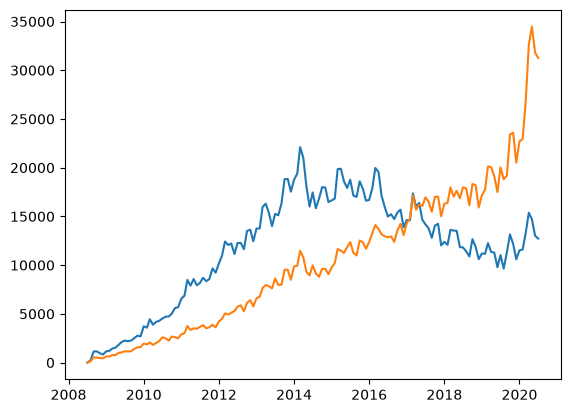

In [21]:
# Now that you've successfully created and styled your chart, can you figure out how to plot both Java 
# and Python next to each other?
pyplot.plot(reshaped.index, reshaped.java)
pyplot.plot(reshaped.index, reshaped.python)

TAG,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
DATE,,,,,,,,,,,,,,
2008-07-01,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2008-08-01,8.0,85.0,511.0,164.0,14.0,0.0,222.0,162.0,28.0,161.0,124.0,0.0,73.0,0.0
2008-09-01,28.0,321.0,1649.0,755.0,105.0,0.0,1137.0,640.0,131.0,482.0,542.0,6.0,290.0,0.0
2008-10-01,15.0,303.0,1989.0,811.0,112.0,0.0,1153.0,725.0,127.0,617.0,510.0,0.0,249.0,0.0
2008-11-01,17.0,259.0,1730.0,735.0,141.0,0.0,958.0,579.0,97.0,504.0,452.0,1.0,160.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-01,317.0,2670.0,8954.0,5107.0,181.0,719.0,13253.0,20483.0,215.0,6672.0,26673.0,5761.0,780.0,3434.0
2020-04-01,406.0,3472.0,10042.0,6820.0,250.0,887.0,15377.0,24634.0,240.0,8060.0,32605.0,7047.0,860.0,4015.0
2020-05-01,386.0,3602.0,9923.0,7063.0,221.0,826.0,14711.0,25196.0,228.0,7917.0,34478.0,6833.0,774.0,4066.0


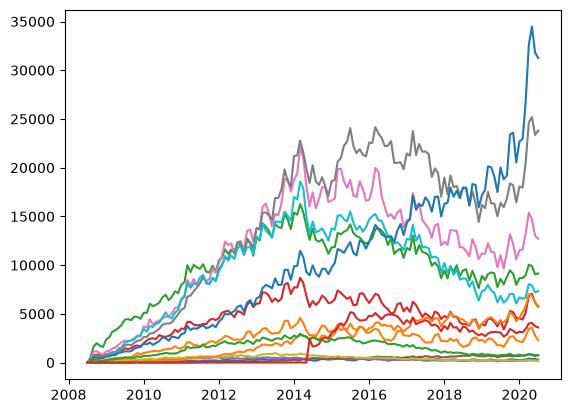

In [22]:
# But what if we wanted to plot all the programming languages on the same chart? 
# We don't want to type out .plot() a million times, right? We can actually just use a for-loop:

for col in reshaped.columns:
    pyplot.plot(reshaped.index, reshaped[col])
reshaped

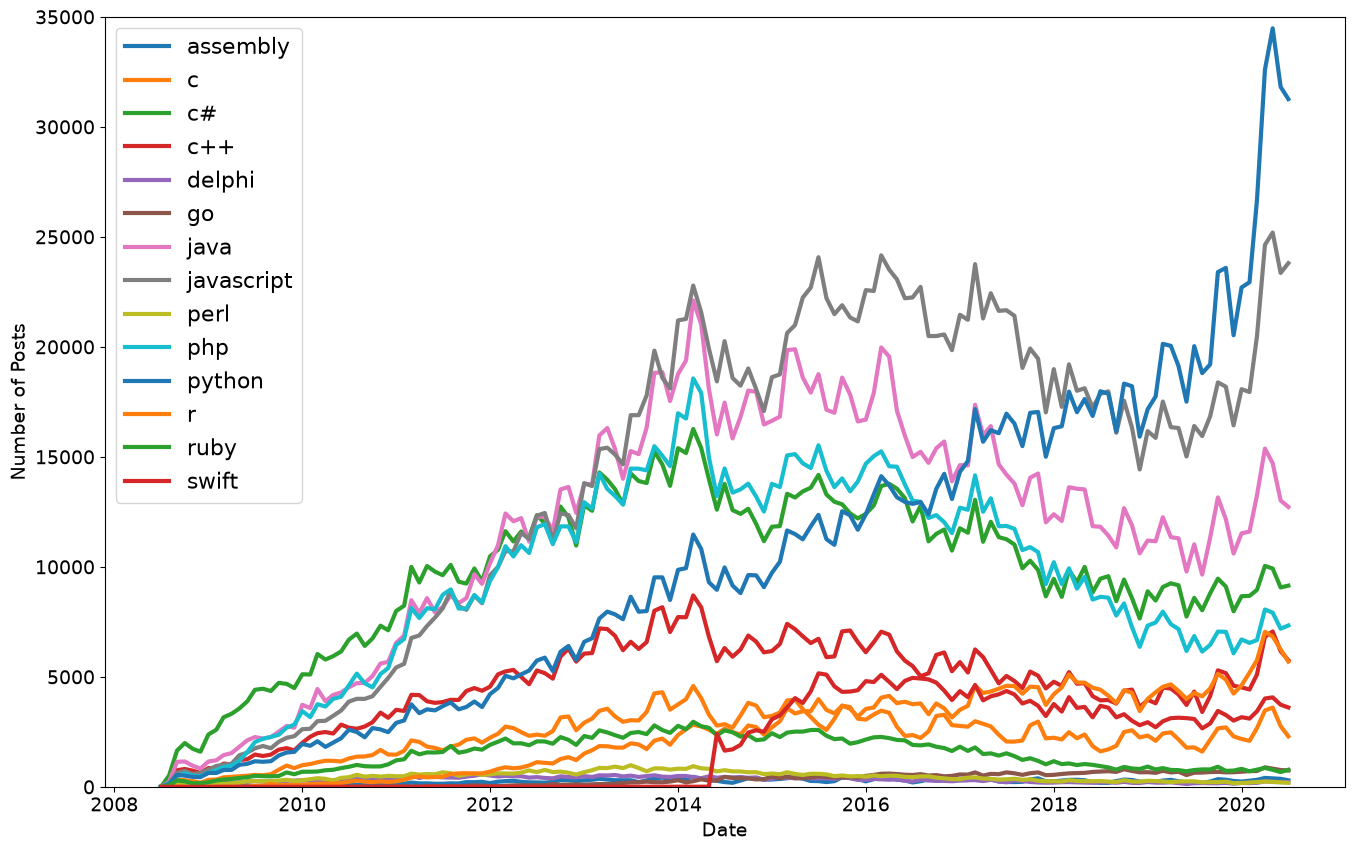

In [28]:
# But wait, which language is which? It's really hard to make out without a legend that tells us which colour 
# corresponds to each language. Let's modify the plotting code to add a label for each line based on the column 
# name (and make the lines thicker at the same time using linewidth). Then let's add a legend to our chart:

pyplot.figure(figsize=(16, 10))
pyplot.xticks(fontsize=14)
pyplot.yticks(fontsize=14)
pyplot.xlabel('Date', fontsize=14)
pyplot.ylabel('Number of Posts', fontsize=14)
pyplot.ylim(0, 35000)
for col in reshaped.columns:
    pyplot.plot(reshaped.index, reshaped[col], linewidth=3, label=reshaped[col].name)
pyplot.legend(fontsize=16)

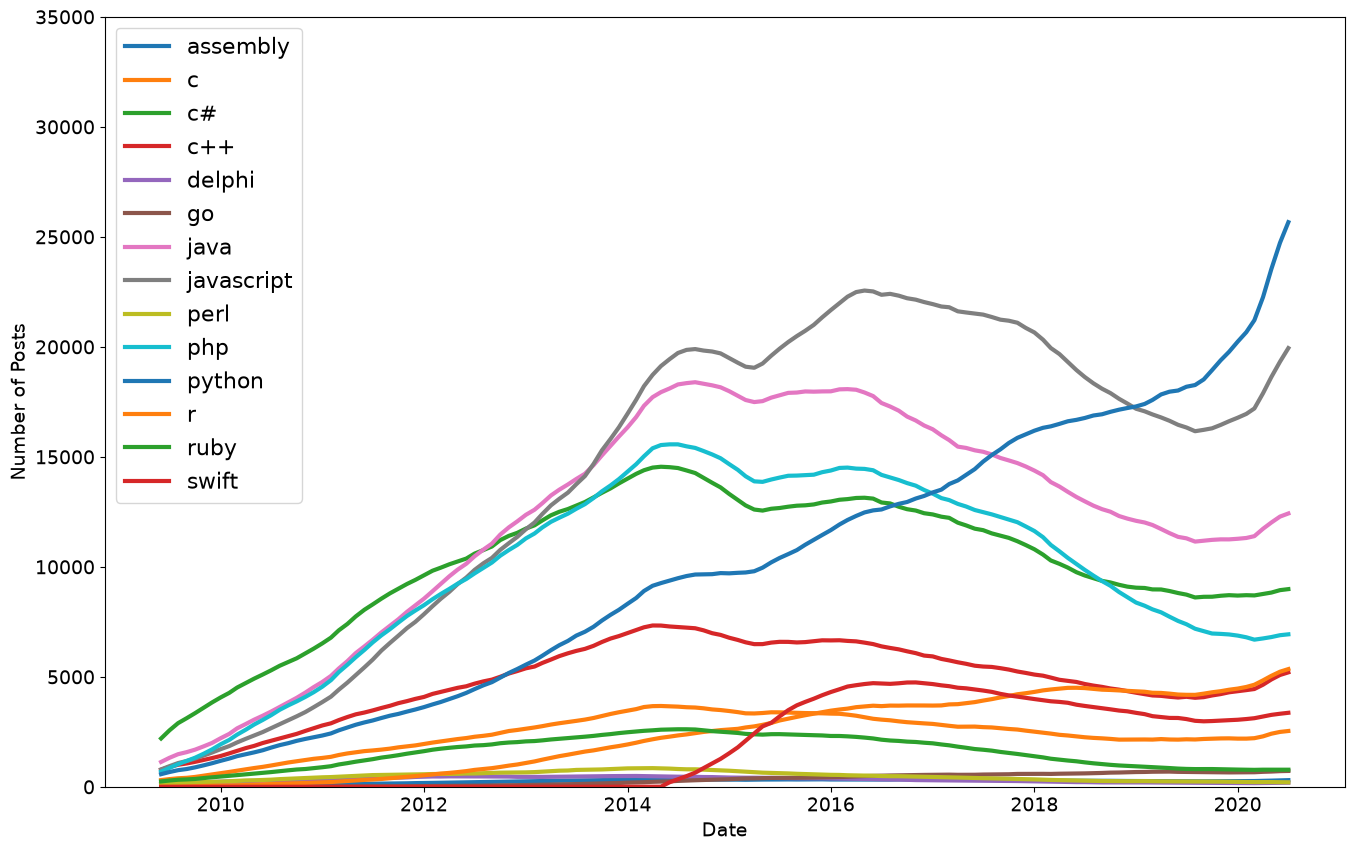

In [32]:
# A useful technique to make a trend apparent is to smooth out the observations by taking an average. 
# By averaging say, 6 or 12 observations we can construct something called the rolling mean. 
# Essentially we calculate the average in a window of time and move it forward by one observation at a time.

rolling_df = reshaped.rolling(window=12).mean()

pyplot.figure(figsize=(16, 10))
pyplot.xticks(fontsize=14)
pyplot.yticks(fontsize=14)
pyplot.xlabel('Date', fontsize=14)
pyplot.ylabel('Number of Posts', fontsize=14)
pyplot.ylim(0, 35000)
for col in rolling_df.columns:
    pyplot.plot(rolling_df.index, rolling_df[col], linewidth=3, label=rolling_df[col].name)
pyplot.legend(fontsize=16)
